Telco Customer Churn

## 1. Setup & Libraries
We begin by importing the necessary libraries and establishing default settings for our visualizations.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## 2. Data Acquisition & Integrity Audit
Next, we load the dataset from the uploaded CSV file (`WA_Fn-UseC_-Telco-Customer-Churn.csv`) and run an initial integrity audit to detect anomalies, check data types, and handle potential type mismatches (such as empty strings in `TotalCharges`).

In [4]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Dimensions:", df.shape)
print("\nColumn Data Types:\n", df.dtypes.value_counts())

# Handle known quirks (e.g., TotalCharges stored as string with blank spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Audit missingness
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df)) * 100
}).query('Missing_Count > 0')
print("\nMissing Values Audit:\n", missing_summary)

# Drop redundant identifier columns and missing records
df_clean = df.drop(columns=['customerID']).dropna()

Dataset Dimensions: (7043, 21)

Column Data Types:
 object     18
int64       2
float64     1
Name: count, dtype: int64

Missing Values Audit:
               Missing_Count  Missing_Pct
TotalCharges             11     0.156183


## 3. Univariate Analysis
We perform a univariate exploration of the key numerical variables (`tenure`, `MonthlyCharges`, `TotalCharges`) by computing descriptive statistics and visualizing their underlying distributions.

In [5]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

def compute_dispersion(data, cols):
    metrics = []
    for col in cols:
        series = data[col]
        metrics.append({
            'Feature': col,
            'Mean': series.mean(),
            'Median': series.median(),
            'Std_Dev': series.std(),
            'IQR': series.quantile(0.75) - series.quantile(0.25),
            'Skewness': series.skew(),
            'Kurtosis': series.kurtosis()
        })
    return pd.DataFrame(metrics)

stats_summary = compute_dispersion(df_clean, numerical_cols)
display(stats_summary)

,Feature,Mean,Median,Std_Dev,IQR,Skewness,Kurtosis
0,tenure,32.421786,29.000,24.545260,46.0000,0.237731,-1.387823
1,MonthlyCharges,64.798208,70.350,30.085974,54.2750,-0.222103,-1.256156
2,TotalCharges,2283.300441,1397.475,2266.771362,3393.2875,0.961642,-0.231799


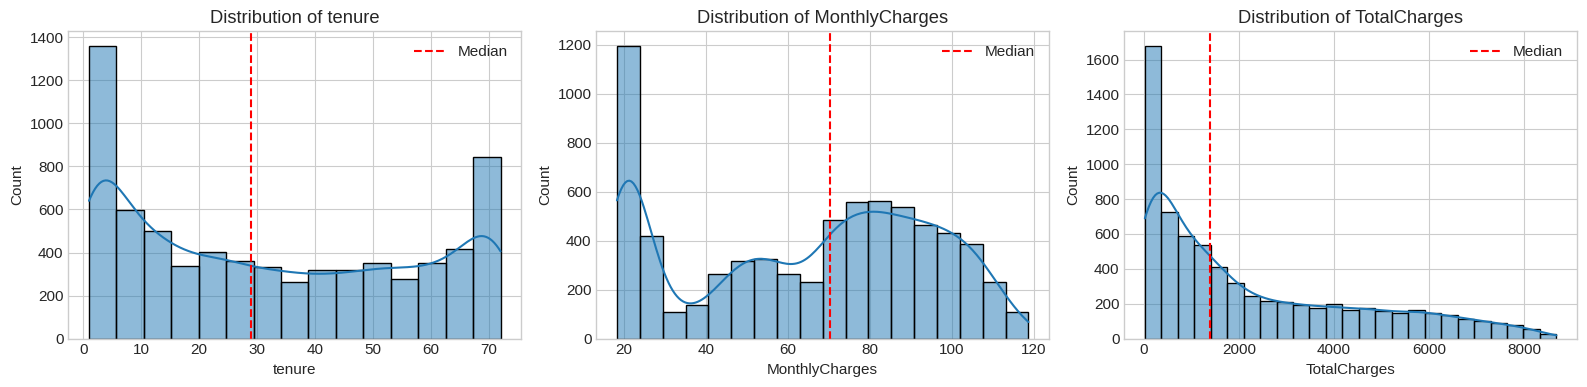

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="#1f77b4")
    axes[i].axvline(df_clean[col].median(), color='red', linestyle='--', label='Median')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()
plt.tight_layout()
plt.show()

## 4. Bivariate & Multivariate Exploration
We analyze relationship metrics among numerical features and evaluate their behavior relative to our target churn outcome variable.

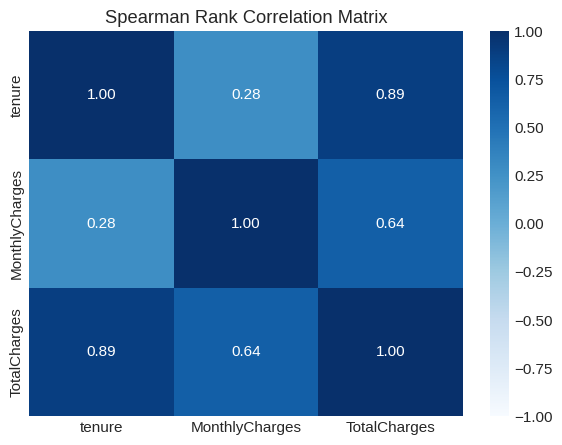

In [7]:
# Correlation Heatmap using non-parametric Spearman rank correlation
plt.figure(figsize=(7, 5))
corr_matrix = df_clean[numerical_cols].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", vmin=-1, vmax=1)
plt.title("Spearman Rank Correlation Matrix")
plt.show()

**Note:** `TotalCharges` is roughly `tenure × MonthlyCharges`, so its strong correlation with `tenure` is largely mechanical rather than an independent insight.

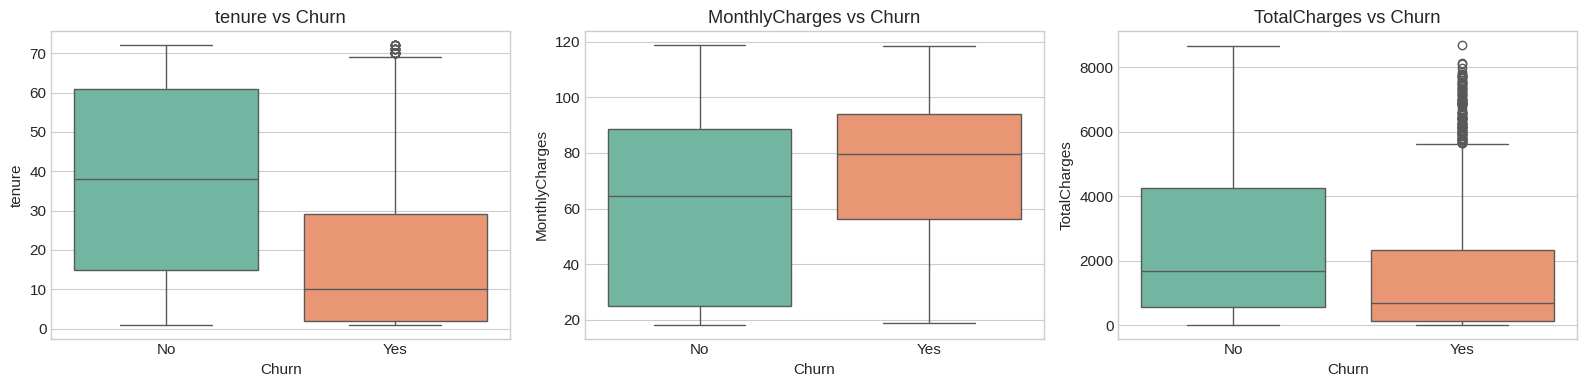

In [8]:
# Boxplots by Target Class (Churn)
# Note: requires df_clean from Section 2 -- run the notebook top to bottom.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Churn', y=col, hue='Churn', data=df_clean, ax=axes[i],
                palette="Set2", legend=False)
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

## 5. Formal Hypothesis Testing
Lastly, we perform statistical tests to determine whether our observed differences are statistically significant.

- **Test 1**: Two-sample Mann-Whitney U test comparing monthly charges distribution.
- **Test 2**: Chi-Square Test of Independence evaluating the association between Contract Type and Churn.

In [9]:
# Test 1: Mann-Whitney U test (Non-parametric t-test alternative)
churn_yes = df_clean[df_clean['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df_clean[df_clean['Churn'] == 'No']['MonthlyCharges']

u_stat, p_val_mw = stats.mannwhitneyu(churn_yes, churn_no, alternative='two-sided')
print(f"Mann-Whitney U Test (MonthlyCharges vs Churn): p-value = {p_val_mw:.4e}")

# Effect size: rank-biserial correlation (range -1..1) and median difference
rank_biserial = 2 * u_stat / (len(churn_yes) * len(churn_no)) - 1
print(f"Rank-biserial correlation = {rank_biserial:.3f}")
print(f"Median MonthlyCharges: churned = {churn_yes.median():.2f}, retained = {churn_no.median():.2f}")

# Test 2: Chi-Square Test of Independence
contingency_table = pd.crosstab(df_clean['Contract'], df_clean['Churn'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Test (Contract vs Churn): Chi2 = {chi2:.2f}, p-value = {p_val_chi2:.4e}")

# Effect size: Cramer's V
n = contingency_table.values.sum()
cramers_v = (chi2 / (n * (min(contingency_table.shape) - 1))) ** 0.5
print(f"Cramer's V = {cramers_v:.3f}")

Mann-Whitney U Test (MonthlyCharges vs Churn): p-value = 8.4672e-54
Rank-biserial correlation = 0.241
Median MonthlyCharges: churned = 79.65, retained = 64.45
Chi-Square Test (Contract vs Churn): Chi2 = 1179.55, p-value = 7.3262e-257
Cramer's V = 0.410
